# 01 — WebDAV exploration

Inventory of the faculty scan shares on `datasilo2.schk.sk`: **how many books, how many pages, how much data** — per faculty and per book — with interactive Plotly charts.

> ⚠️ Requires VPN. Full listings are cached to `.cache/stats/<source>.json`, so re-running does **not** re-walk the WebDAV servers — delete the cache files to force a refresh.

Known share layout: `<root>/CVI_OPACID_<id>/stream_pages_tif/*.tif`, uncompressed RGB TIFF @ 300 DPI, ~24 MB/page.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import plotly.express as px
import plotly.io as pio

from evilflowers_books_digitalizer import BookSource, LocalCache, load_settings

pio.templates.default = "plotly_white"
pd.options.display.float_format = "{:,.1f}".format

settings = load_settings()
cache = LocalCache(settings.cache_dir)
settings.sources

/Users/jdubec/Projects/EvilFlowers/evilflowers-books-digitalizer/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'svf': WebDAVSource(name='svf', url='https://datasilo2.schk.sk/SVF-scan'),
 'sjf': WebDAVSource(name='sjf', url='https://datasilo2.schk.sk/SJF-scan'),
 'fad': WebDAVSource(name='fad', url='https://datasilo2.schk.sk/FAD-scan'),
 'fei': WebDAVSource(name='fei', url='https://datasilo2.schk.sk/FEI-scan'),
 'mtf': WebDAVSource(name='mtf', url='https://datasilo2.schk.sk/MTF-scan')}

## 1. Connectivity check

One request per share — verifies VPN + credentials and shows book counts.

In [3]:
sources = {key: BookSource(cfg) for key, cfg in settings.sources.items()}

for key, source in sources.items():
    try:
        books = source.list_books()
        print(f"{key:>4}: {len(books):4d} books   (e.g. {books[0]})")
    except Exception as exc:  # noqa: BLE001 — report, keep checking the rest
        print(f"{key:>4}: FAILED — {exc}")

 svf:  150 books   (e.g. CVI_OPACID_SVF_8005000251)
 sjf:  134 books   (e.g. CVI_OPACID_SJF_8001029344)
 fad:  164 books   (e.g. CVI_OPACID_FA_0415128269)
 fei:  162 books   (e.g. CVI_OPACID_FEI_13370324)
 mtf:  270 books   (e.g. CVI_OPACID_MTF_8005000979)


## 2. Full inventory

Walk every book directory and record its TIFF pages and sizes. **Slow on first run** (~880 books → one request each), cached afterwards.

In [4]:
all_stats = {}
for key, source in sources.items():
    stats = cache.load_stats(key)
    if stats is None:
        stats = source.stats(progress=True)
        cache.save_stats(stats)
    all_stats[key] = stats

books_df = pd.DataFrame(
    {
        "faculty": book.source,
        "book_id": book.book_id,
        "n_pages": book.n_pages,
        "size_mb": book.total_bytes / 1e6,
        "size_gb": book.total_bytes / 1e9,
    }
    for stats in all_stats.values()
    for book in stats.books
)
books_df["mb_per_page"] = (books_df.size_mb / books_df.n_pages).where(books_df.n_pages > 0)
books_df.head()

mtf: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [02:23<00:00,  1.88book/s]


,faculty,book_id,n_pages,size_mb,size_gb,mb_per_page
0,svf,CVI_OPACID_SVF_8005000251,297,"6,654.6",6.7,22.4
1,svf,CVI_OPACID_SVF_8005000987,633,"16,345.9",16.3,25.8
2,svf,CVI_OPACID_SVF_800500124_X,777,"20,017.4",20.0,25.8
3,svf,CVI_OPACID_SVF_8005001274,290,"5,727.2",5.7,19.7
4,svf,CVI_OPACID_SVF_8005001371,341,"8,224.3",8.2,24.1


## 3. Headline numbers

In [5]:
print(
    f"TOTAL: {len(books_df):,} books | {books_df.n_pages.sum():,} pages | "
    f"{books_df.size_gb.sum():,.1f} GB | "
    f"median book: {books_df.n_pages.median():.0f} pages / {books_df.size_gb.median():.1f} GB"
)

summary = (
    books_df.groupby("faculty")
    .agg(
        books=("book_id", "count"),
        pages=("n_pages", "sum"),
        total_gb=("size_gb", "sum"),
        median_pages=("n_pages", "median"),
        median_gb=("size_gb", "median"),
        avg_mb_per_page=("mb_per_page", "mean"),
        empty_books=("n_pages", lambda s: int((s == 0).sum())),
    )
    .sort_values("total_gb", ascending=False)
)
summary

TOTAL: 880 books | 233,183 pages | 6,369.1 GB | median book: 225 pages / 6.5 GB


,books,pages,total_gb,median_pages,median_gb,avg_mb_per_page,empty_books
faculty,,,,,,,
mtf,270,70367,"1,739.1",215.0,5.4,25.0,0
svf,150,49817,"1,443.0",293.0,8.4,30.1,0
fad,164,39277,"1,151.9",205.5,6.2,30.9,0
fei,162,39377,"1,108.5",209.0,6.3,28.7,0
sjf,134,34345,926.5,219.0,6.4,27.6,0


## 4. Per-faculty comparison

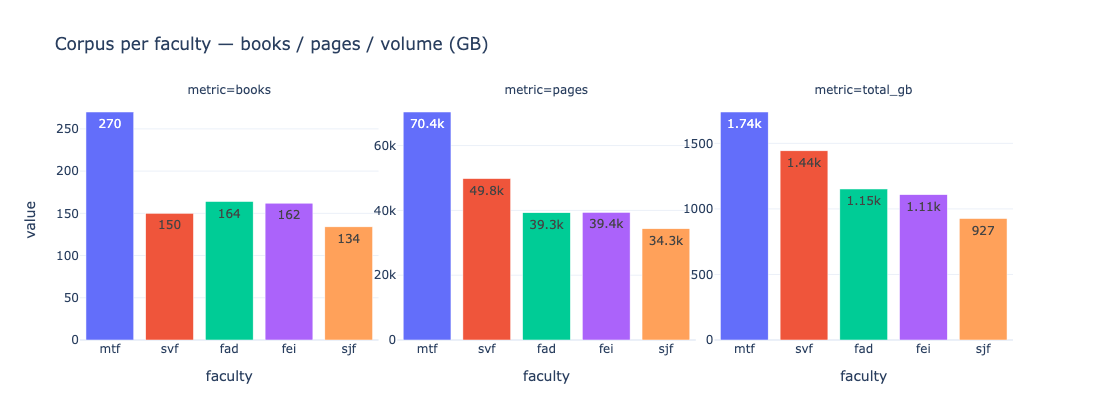

In [6]:
per_faculty = summary.reset_index()

fig = px.bar(
    per_faculty.melt(
        id_vars="faculty",
        value_vars=["books", "pages", "total_gb"],
        var_name="metric",
    ),
    x="faculty",
    y="value",
    color="faculty",
    facet_col="metric",
    title="Corpus per faculty — books / pages / volume (GB)",
    text_auto=".3s",
)
fig.update_yaxes(matches=None, showticklabels=True)
fig.update_layout(showlegend=False, height=420)
fig.show()

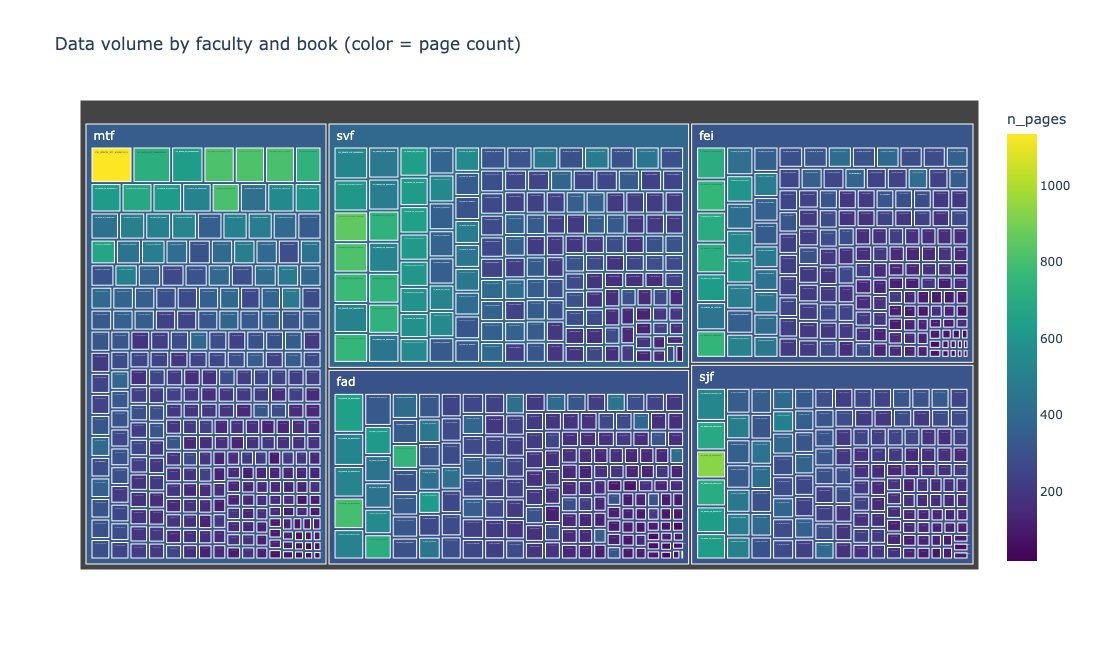

In [7]:
# Every book at a glance — area = data volume, hover for details, click a faculty to zoom in
fig = px.treemap(
    books_df[books_df.n_pages > 0],
    path=["faculty", "book_id"],
    values="size_gb",
    color="n_pages",
    color_continuous_scale="Viridis",
    title="Data volume by faculty and book (color = page count)",
    hover_data={"size_gb": ":.2f", "n_pages": True},
)
fig.update_layout(height=650)
fig.show()

## 5. Book size distributions

How big is a *typical* book — and how bad are the outliers we'll have to process?

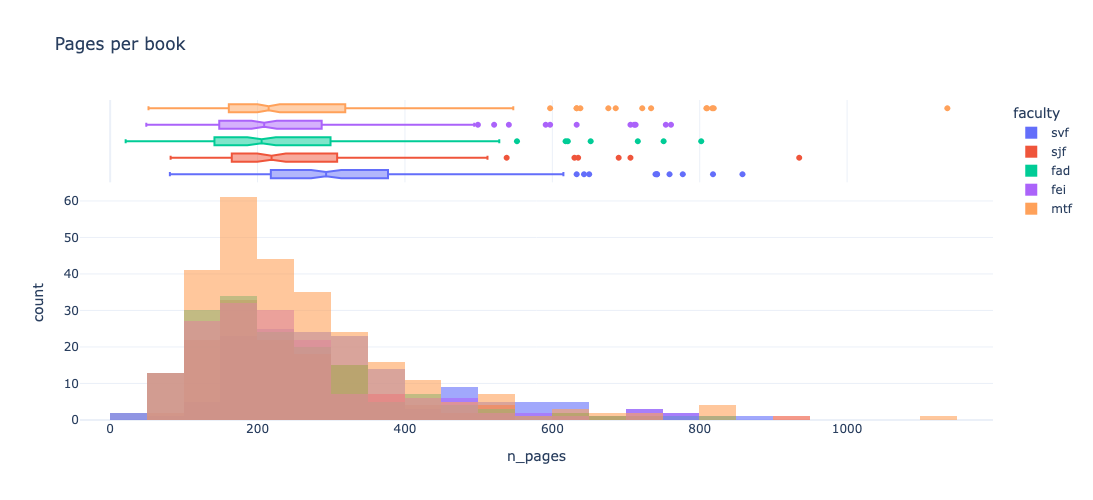

In [8]:
fig = px.histogram(
    books_df[books_df.n_pages > 0],
    x="n_pages",
    color="faculty",
    marginal="box",
    nbins=50,
    barmode="overlay",
    opacity=0.6,
    title="Pages per book",
    hover_data=["book_id"],
)
fig.update_layout(height=500)
fig.show()

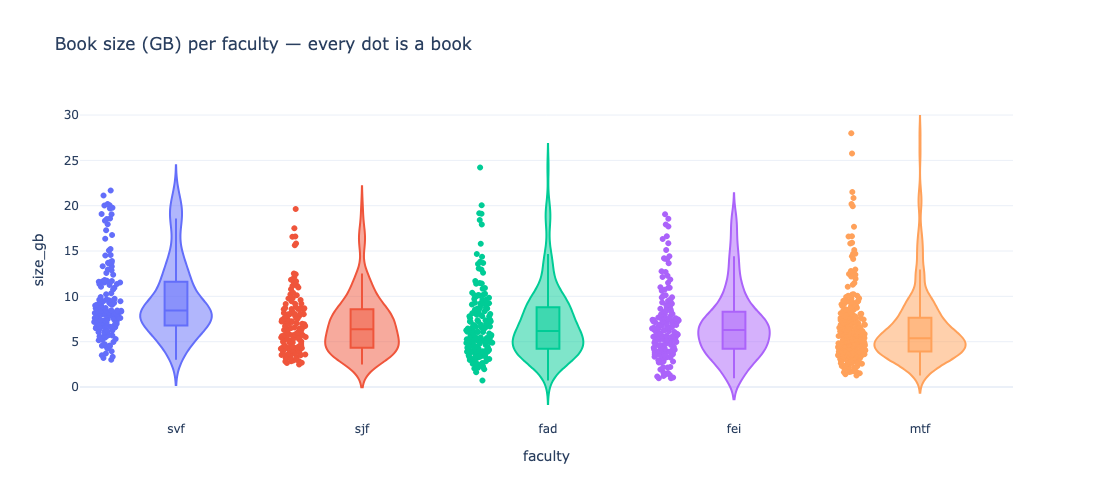

In [9]:
fig = px.violin(
    books_df[books_df.n_pages > 0],
    x="faculty",
    y="size_gb",
    color="faculty",
    box=True,
    points="all",
    hover_data=["book_id", "n_pages"],
    title="Book size (GB) per faculty — every dot is a book",
)
fig.update_layout(showlegend=False, height=500)
fig.show()

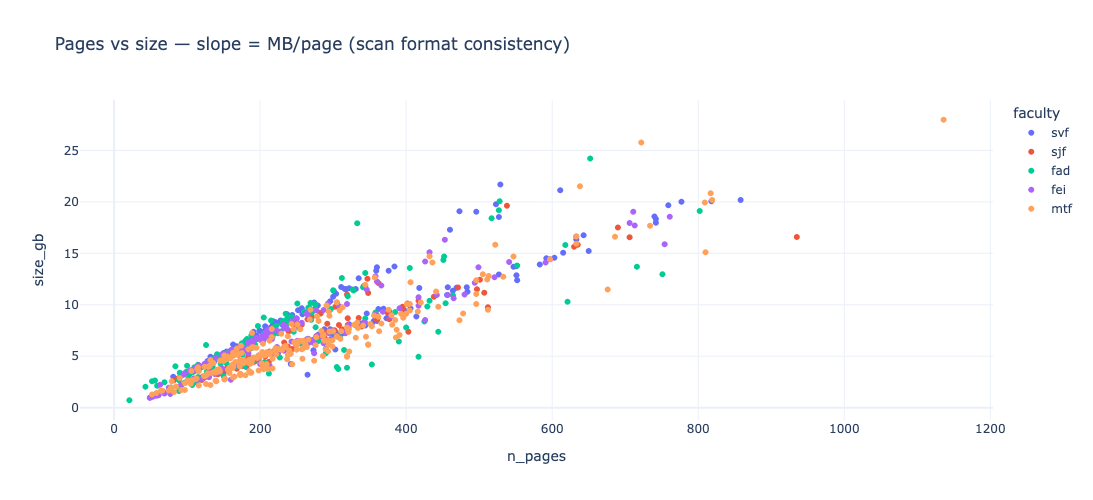

In [10]:
# Pages vs size — books off the common ~24 MB/page line have a different scan format
fig = px.scatter(
    books_df[books_df.n_pages > 0],
    x="n_pages",
    y="size_gb",
    color="faculty",
    hover_name="book_id",
    hover_data={"mb_per_page": ":.1f"},
    title="Pages vs size — slope = MB/page (scan format consistency)",
)
fig.update_layout(height=500)
fig.show()

## 6. Outliers & data quality

Empty directories and odd MB/page values signal scan problems or a different layout — check before batch processing.

In [11]:
empty = books_df[books_df.n_pages == 0]
print(f"{len(empty)} books with no TIFF pages:")
display(empty[["faculty", "book_id"]])

print("\n10 largest books:")
display(books_df.nlargest(10, "size_gb")[["faculty", "book_id", "n_pages", "size_gb", "mb_per_page"]])

print("\nUnusual MB/page (outside 20–30 MB):")
weird = books_df[(books_df.mb_per_page < 20) | (books_df.mb_per_page > 30)]
display(weird[["faculty", "book_id", "n_pages", "size_gb", "mb_per_page"]])

0 books with no TIFF pages:


,faculty,book_id



10 largest books:


,faculty,book_id,n_pages,size_gb,mb_per_page
748,mtf,CVI_OPACID_MTF_8080631131,1136,28.0,24.6
833,mtf,CVI_OPACID_MTF_9788089291045,722,25.8,35.7
336,fad,CVI_OPACID_FA_8090148666,652,24.2,37.2
55,svf,CVI_OPACID_SVF_8088905605,529,21.7,41.0
775,mtf,CVI_OPACID_MTF_9788025457542,638,21.5,33.7
136,svf,CVI_OPACID_SVF_Stavitelske_konstrukcie_1,611,21.1,34.6
857,mtf,CVI_OPACID_MTF_Matematika_2_1073,817,20.8,25.5
143,svf,CVI_OPACID_SVF_Vnutrozemne_vodne_cesty,858,20.2,23.5
868,mtf,CVI_OPACID_MTF_Tech_tvarnenia_zliev_zvarania_2945,819,20.2,24.6
326,fad,CVI_OPACID_FA_8080760357,528,20.1,38.0



Unusual MB/page (outside 20–30 MB):


,faculty,book_id,n_pages,size_gb,mb_per_page
3,svf,CVI_OPACID_SVF_8005001274,290,5.7,19.7
9,svf,CVI_OPACID_SVF_8005006322,191,6.6,34.5
11,svf,CVI_OPACID_SVF_8005006470,303,5.7,18.6
12,svf,CVI_OPACID_SVF_8005006535,207,7.9,38.2
18,svf,CVI_OPACID_SVF_8005008279,137,4.5,32.8
...,...,...,...,...,...
867,mtf,CVI_OPACID_MTF_Starostlivost_akost_vyrobkov,170,5.2,30.6
871,mtf,CVI_OPACID_MTF_Teoria_tvarnenia,163,5.3,32.7
873,mtf,CVI_OPACID_MTF_Teoria_tvarnenia_nastroje,344,11.9,34.7
874,mtf,CVI_OPACID_MTF_Teoria_zlievania,79,2.6,32.6


## 7. Processing estimates

Back-of-envelope for the batch run: download volume and OCR time (calibrate s/page in notebook 02).

In [12]:
OCR_SECONDS_PER_PAGE = 2.0  # calibrate with notebook 02 on this machine

total_pages = books_df.n_pages.sum()
total_gb = books_df.size_gb.sum()
print(f"download volume : {total_gb:,.0f} GB")
print(f"OCR wall-clock  : ~{total_pages * OCR_SECONDS_PER_PAGE / 3600:,.0f} h "
      f"(at {OCR_SECONDS_PER_PAGE}s/page, parallelized by OCRmyPDF)")
print(f"\nper faculty (GB):")
print(summary.total_gb.round(0).to_string())

download volume : 6,369 GB
OCR wall-clock  : ~130 h (at 2.0s/page, parallelized by OCRmyPDF)

per faculty (GB):
faculty
mtf   1,739.0
svf   1,443.0
fad   1,152.0
fei   1,109.0
sjf     927.0


---
**Next:** `02_single_book_pipeline.ipynb` — download one (small!) book, experiment with TIFF → searchable PDF/A, and calibrate OCR speed. Use the violin/treemap above to pick a small book.